In [ ]:
# Shared project setup for imports and file locations
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
FIGURES_DIR = PROJECT_ROOT / 'figures'

def resolve_path(path):
    candidate = Path(path)
    if candidate.exists():
        return candidate
    text = str(path).replace('\\', '/')
    name = Path(text).name
    special = {
        'positive_controls.pkl': ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl',
        'negative_controls.pkl': ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl',
        'Ten_positive_controls_1119.pkl': ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl',
        'Ten_negative_controls_1119.pkl': ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl',
        'fcg.txt': DATA_DIR / 'fcg.txt',
    }
    if name in special:
        return special[name]
    matches = [p for p in PROJECT_ROOT.rglob(name) if '.ipynb_checkpoints' not in p.parts and '.git' not in p.parts]
    if len(matches) == 1:
        return matches[0]
    if (text.startswith('/Users/') or text.startswith('/home/') or ':\\' in text) and '.' not in name:
        return PROJECT_ROOT
    return candidate

from pdm_learn.preprocessing import build_density_map, density_centers, densitymap, drop_nan, extract, mut_trim, normalize, trim, trim_pairs
from pdm_learn.modeling import KFold_PR, LOOCV, LOOCV_grouped_plot, area_table, core_predict, heatmap, importance_test, ks_pvalue
from pdm_learn.simulation import eps, partition


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from itertools import compress
from scipy import stats
import random
from bisect import bisect
import warnings
import xgboost as xgb
import time

In [3]:
prot_int = pd.read_table(DATA_DIR / 'fcg.txt')
mask = prot_int['Organism'].str.contains('Human')
prot_int_human = prot_int[mask].reset_index(drop=True)
subunits = prot_int_human.iloc[:,-7].to_numpy()
subunits

array(['ITGAV;ITGAV;ITGAV;ITGB5;ITGB5;ITGB5',
       'ITGAV;ITGAV;ITGAV;ITGB6;ITGB6;ITGB6', 'ITGB3;ITGB3;ITGA2B;ITGA2B',
       'ITGB1;ITGB1;ITGA5;ITGA5', 'ITGB1;ITGB1;ITGA3;ITGA3',
       'ITGB1;ITGB1;ITGA6;ITGA6', 'ITGB1;ITGB1;ITGA4;ITGA4',
       'ITGB1;ITGB1;ITGA2;ITGA2', 'ITGB1;ITGB1;ITGB1;ITGAV;ITGAV;ITGAV',
       'ITGB1;ITGB1;ITGB1;ITGA8;ITGA8;ITGA8',
       'ITGB1;ITGB1;ITGB1;ITGB1;ITGA9;ITGA9;ITGA9;ITGA9',
       'ITGB3;ITGB3;ITGB3;ITGB3;ITGB3;ITGAV;ITGAV;ITGAV;ITGAV;ITGAV',
       'ITGA10;ITGA10;ITGA10;ITGB1;ITGB1;ITGB1',
       'ITGB1;ITGB1;ITGB1;ITGB1;ITGA11;ITGA11;ITGA11;ITGA11',
       'ITGA4;ITGA4;ITGB7;ITGB7', 'ITGB5;ITGB5;ITGA3;ITGA3',
       'ITGB4;ITGB4;ITGA3;ITGA3',
       'EXOC5;EXOC5;EXOC5;EXOC3;EXOC3;EXOC3;EXOC8;EXOC8;EXOC8;EXOC6;EXOC6;EXOC6;EXOC4;EXOC4;EXOC4;EXOC2;EXOC2;EXOC2;EXOC1;EXOC1;EXOC1;EXOC7;EXOC7;EXOC7',
       'STK4;SAV1', 'STK3;SAV1',
       'OFD1;OFD1;OFD1;KIAA0753;KIAA0753;KIAA0753;CEP20;CEP20;CEP20',
       'TTBK2;TTBK2;TTBK2;CEP164;CEP164;CEP164'

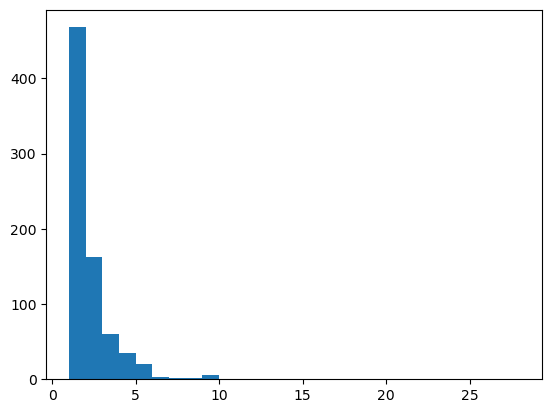

,Gene,Times Used
0,ITGAV,4
1,ITGB5,2
2,ITGB6,1
3,ITGB3,2
4,ITGA2B,1
...,...,...
763,PDE6D,1
764,INPP5E,1
765,CNGA3,1
766,CNGB3,1


In [4]:
used_gene = np.array([])
times_used = np.array([])
for str in subunits:
    for gene in str.strip().split(';'):
        if gene not in used_gene:
            num = 0
            for str2 in subunits:
                if gene in str2:
                    num+=1
            used_gene = np.append(used_gene, gene)
            times_used = np.append(times_used, num)

plt.hist(times_used, bins=np.arange(times_used.min(), times_used.max()+1))
plt.show()
pd.DataFrame({'Gene':used_gene, 'Times Used':times_used.astype(int)})

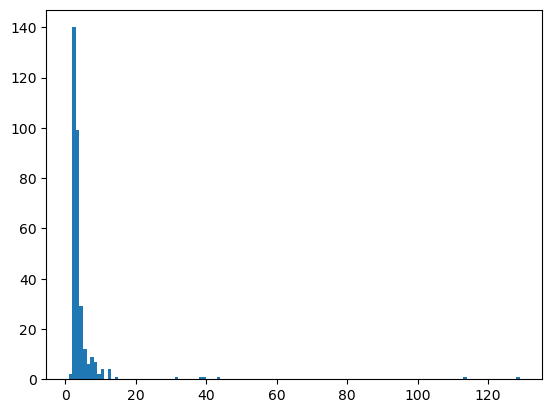

,Functional Group,Gene Number
0,Cell adhesion mediated by integrin,2
1,Cell adhesion mediated by integrin,2
2,Cell adhesion mediated by integrin,2
3,Cell adhesion mediated by integrin,2
4,Cell adhesion mediated by integrin,2
...,...,...
316,Visual perception,2
317,Visual perception,2
318,Visual perception,2
319,Visual perception,2


In [5]:
num_gene = np.array([])
for str in subunits:
    arr = str.strip().split(';')
    used = []
    num = 0
    for i in arr:
        if i not in used:
            used.append(i)
            num+=1
    num_gene = np.append(num_gene, num)

plt.hist(num_gene, bins=np.arange(num_gene.min(), num_gene.max()+1))
plt.show()
pd.DataFrame({'Functional Group':prot_int_human.iloc[:,0].to_numpy(), 'Gene Number':num_gene.astype(int)})

In [12]:
used = np.array([])
positive = np.array([[None,None]])
for str in subunits:
    genes = str.strip().split(';')
    temp = None
    for gene in genes:
        if gene not in used and gene != temp:
            if temp == None:
                temp = gene
            else:
                used = np.append(used, [temp,gene])
                positive = np.concatenate((positive, [[temp, gene]]))
                temp = None
    temp = None

positive = np.delete(positive, 0, 0)
positive = [f'{p1}.{p2}' for p1, p2 in positive]
np.savetxt(DATA_DIR / 'positive_pairs.csv', positive, delimiter=",", fmt='%s')

In [11]:
used = np.array([])
negative = np.array([[None,None]])
for n in range(len(subunits)):
    genes = subunits[n].strip().split(';')
    for gene in genes:
        done = False
        if gene not in used:
            for m in range(n+1,len(subunits)):
                match = subunits[m].strip().split(';')
                if gene not in match:
                    for temp in match:
                        if temp not in used:
                            used = np.append(used, [gene, temp])
                            negative = np.concatenate((negative, [[gene, temp]]))
                            done = True
                            break
                if done:
                    break

negative = np.delete(negative, 0, 0)
negative

array([['ITGAV', 'ITGB3'],
       ['ITGB5', 'ITGB6'],
       ['ITGA2B', 'ITGB1'],
       ['ITGA5', 'ITGA3'],
       ['ITGA6', 'ITGA4'],
       ['ITGA2', 'ITGA8'],
       ['ITGA9', 'ITGA10'],
       ['ITGA11', 'ITGB7'],
       ['ITGB4', 'EXOC5'],
       ['EXOC3', 'STK4'],
       ['EXOC8', 'SAV1'],
       ['EXOC6', 'STK3'],
       ['EXOC4', 'OFD1'],
       ['EXOC2', 'KIAA0753'],
       ['EXOC1', 'CEP20'],
       ['EXOC7', 'TTBK2'],
       ['CEP164', 'GLI3'],
       ['CCDC92', 'DZIP1'],
       ['DCDC2', 'CEP290'],
       ['MAPK8IP1', 'CCP110'],
       ['IQCB1', 'CC2D2A'],
       ['NPHP1', 'DVL2'],
       ['PKD1', 'NPHP4'],
       ['RPGRIP1L', 'TMEM67'],
       ['INVS', 'MKS1'],
       ['SYNE2', 'BBS12'],
       ['MKKS', 'AHI1'],
       ['HAP1', 'TUBG1'],
       ['TUBGCP3', 'SPAG1'],
       ['TUBGCP6', 'DNAAF5'],
       ['TUBGCP5', 'DNAAF2'],
       ['TUBGCP2', 'RAB8A'],
       ['TUBGCP4', 'PCM1'],
       ['HOOK2', 'CFAP410'],
       ['NEK1', 'B9D2'],
       ['SPATA7', 'B9D1'],
       ['DY

In [13]:
data = pd.read_csv(DATA_DIR / 'Trimmed data' / 'dataset_trimmed_v3.csv').dropna().reset_index(drop=True)

oncogenes = pd.read_csv(DATA_DIR / 'oncogene.txt').to_numpy().flatten()
oncogenes = np.append(oncogenes,'MYCL')
oncogenes = np.array(list(set(oncogenes).intersection(data.iloc[:,0])))

In [14]:
input_data = data.copy().sample(frac=1, random_state=1, ignore_index=True)
input_data['oncogene'] = np.isin(input_data.iloc[:,0], oncogenes)

# remove specific columns
# drop_index = input_data.columns[['gene_exp' in i for i in input_data.columns]]
# input_data.drop(drop_index, axis=1, inplace=True)

# split into positive and negative
positive = input_data.iloc[list(compress(range(len(input_data)), input_data.iloc[:,-1]))].reset_index(drop=True)
negative = input_data.drop(list(compress(range(len(input_data)), input_data.iloc[:,-1]))).reset_index(drop=True)
input_data

,gene name,gene_exp.copy_num.0,gene_exp.copy_num.1,gene_exp.copy_num.2,gene_exp.copy_num.3,gene_exp.copy_num.4,gene_exp.copy_num.5,gene_exp.copy_num.6,gene_exp.copy_num.7,gene_exp.copy_num.8,...,gene_mut.CRISPR.5,gene_mut.CRISPR.6,gene_mut.CRISPR.7,gene_mut.CRISPR.8,gene_mut.CRISPR.9,gene_mut.CRISPR.10,gene_mut.CRISPR.11,gene_mut.CRISPR.12,gene_mut.CRISPR.13,oncogene
0,CDIPT,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165074,-6.824323,...,-5.660005,-0.835259,-4.799130,-1.605805,-5.464549,-2.889809,-6.439886,-4.463124,-6.670505,False
1,CDCA4,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.162837,-6.221919,...,-6.025409,-0.443507,-4.928305,-1.763472,-5.813376,-5.078061,-6.658196,-6.349928,-6.672030,False
2,MPP3,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.162995,-6.800850,...,-5.157837,-0.530900,-3.977192,-1.702240,-4.838713,-4.569474,-6.449875,-6.581889,-6.671420,False
3,PKIG,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.103194,-6.122665,...,-6.287955,-0.442910,-5.337388,-1.749661,-6.125389,-4.897825,-6.663344,-6.633388,-6.672030,False
4,KDM5C,-6.904531,-6.649909,-7.137922,-7.165472,-7.165493,-7.165493,-7.165493,-6.976035,-5.139544,...,-4.279963,-0.822265,-3.591963,-1.441173,-4.496225,-3.501257,-6.425536,-5.603800,-6.671712,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15300,ARPC1B,-7.165490,-7.156091,-6.760472,-6.771147,-7.156958,-7.165491,-7.165493,-6.852016,-5.822283,...,-5.627036,-0.444241,-4.410658,-1.772109,-5.743012,-5.141167,-6.664346,-6.654508,-6.672032,False
15301,GOT1L1,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165491,-7.117486,...,-5.322053,-0.500386,-4.074309,-1.754566,-4.965516,-4.628132,-6.539066,-6.016090,-6.671868,False
15302,SLC6A6,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.087535,-5.196264,...,-4.808403,-0.479611,-3.702725,-1.770177,-4.899679,-5.214172,-6.613965,-6.663884,-6.672012,False
15303,ADAM2,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165491,-7.117393,...,-5.093460,-0.442254,-3.738686,-1.830388,-4.848155,-5.420074,-6.518205,-6.668807,-6.671761,False


In [15]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [16]:
scores = core_predict(positive.iloc[:,1:-1].values, negative.iloc[:,1:-1].values, 100, model='GBR', ks_test=True, features_left=None)
result = pd.concat([negative.iloc[:,0], pd.Series(scores)], axis=1)
result = result.sort_values(by=result.columns[-1], ascending=False)
# result.to_csv(ARTIFACTS_DIR / 'results' / 'oncogene_ranking.csv', index=False)
result

,gene name,0
6479,HNF1A,1.034683
13913,HDAC7,1.022746
15150,SATB2,1.005980
5836,TRPS1,1.005505
8183,EBF1,1.003267
...,...,...
5818,ASB17,-0.044684
9984,KRTAP26-1,-0.045529
57,MAGEB18,-0.046192
12646,RGS8,-0.047150


In [17]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


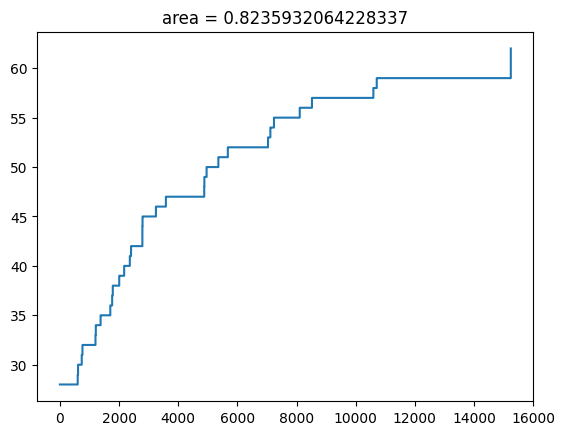

In [25]:
curr = time.time()
lr_area, lr_x, lr_y = LOOCV(positive.iloc[:,1:-1].values, negative.iloc[:,1:-1].values, 25, 
      model='LR', ks_test=True, features_left=250, graph=True, equation=True)
lr_time = time.time()-curr

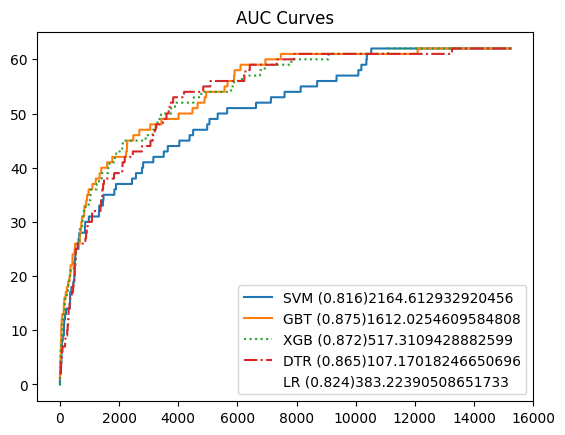

In [26]:
plt.plot(svm_x, svm_y, label = "SVM ("+str(round(svm_area, 3))+")"+str(svm_time))
plt.plot(gbr_x, gbr_y, label = "GBT ("+str(round(gbr_area, 3))+")"+str(gbr_time), linestyle="-")
plt.plot(xgb_x, xgb_y, label = "XGB ("+str(round(xgb_area, 3))+")"+str(xgb_time), linestyle=":")
plt.plot(dtr_x, dtr_y, label = "DTR ("+str(round(dtr_area, 3))+")"+str(dtr_time), linestyle="-.")
plt.plot(lr_x, lr_y, label = "LR ("+str(round(lr_area, 3))+")"+str(lr_time), linestyle=" ")
plt.title("AUC Curves")
plt.legend()
plt.show()

In [44]:
graphs = [method_area, method_x, method_y, pearson_area, pearson_x, pearson_y, spearman_area, spearman_x, spearman_y,]
pd.Series(graphs).to_csv(r"C:\Users\justi\Coding\Coding_Project\Han Xu\Trimmed data\graphs.csv", index = False)

In [8]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [71]:
feature_arr = [10, 20, 50, 100, 124, 150, 200, 250, 300, 349]
areas = area_table(positive.iloc[:,1:-1].values, negative.iloc[:,1:-1].values, 20, 
                       model='GBR', feat_arr=feature_arr)

10
20
50
100
124
150
200
250
300
349


In [23]:
input_data = data.copy().sample(frac=1, random_state=1, ignore_index=True)
input_data['oncogene'] = np.isin(input_data.iloc[:,0], oncogenes)

# remove specific columns
drop_index = input_data.columns[['CRISPR' in i for i in input_data.columns]]
input_data.drop(drop_index, axis=1, inplace=True)
drop_index = input_data.columns[['copy_num' in i for i in input_data.columns]]
input_data.drop(drop_index, axis=1, inplace=True)
drop_index = input_data.columns[['gene_exp' in i for i in input_data.columns]]
input_data.drop(drop_index, axis=1, inplace=True)

# split into positive and negative
positive = input_data.iloc[list(compress(range(len(input_data)), input_data.iloc[:,-1]))].reset_index(drop=True)
negative = input_data.drop(list(compress(range(len(input_data)), input_data.iloc[:,-1]))).reset_index(drop=True)

feature_arr = [1, 2, 5, 7, 10, 13]
areas = area_table(positive.iloc[:,1:-1].values, negative.iloc[:,1:-1].values, 20, 
                       model='GBR', feat_arr=feature_arr)
print(areas)

1
2
5
7
10
13
[0.7502253662995911, 0.7553759914001067, 0.7271829847385751, 0.7402478817683954, 0.7467454143777351, 0.750943787508147]


In [72]:
feature_area = np.array([feature_arr, areas])

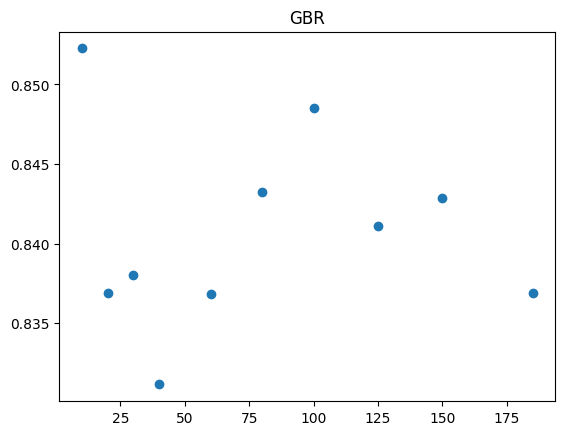

In [8]:
plt.scatter([10, 20, 30, 40, 60, 80, 100, 125, 150, 185], [0.8522559907229497, 0.8368654827705877, 0.8380526235599834, 0.8311466806612438, 0.836799883190425, 0.8432476870857704, 0.8485379758085677, 0.8410987718065701, 0.8428678443554736, 0.8368633666550985])
plt.title('GBR')
plt.show()

In [9]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [9]:
p_val = ks_pvalue(positive.iloc[:,1:-1].values, negative.iloc[:,1:-1].values)

In [10]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


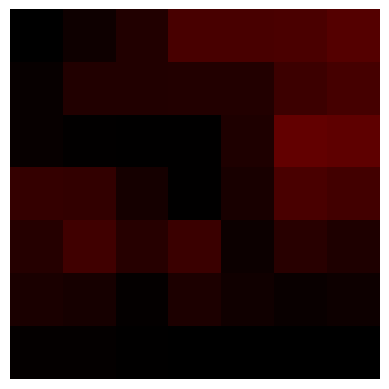

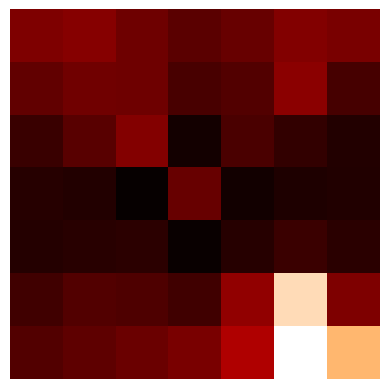

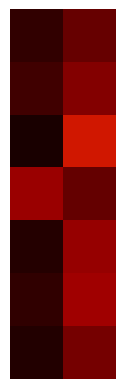

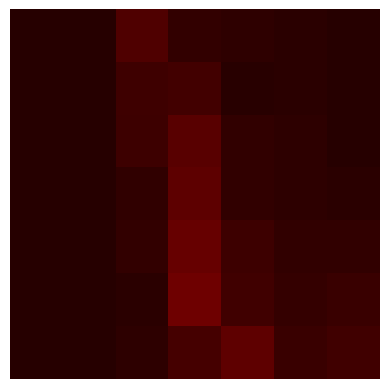

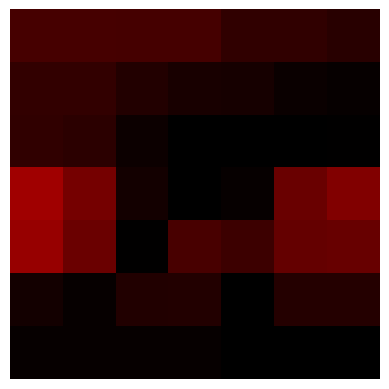

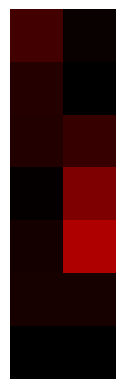

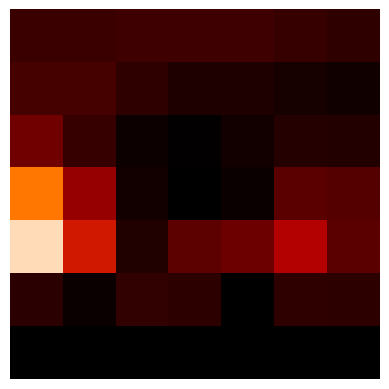

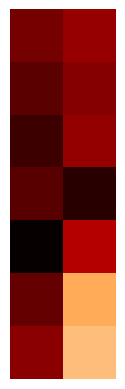

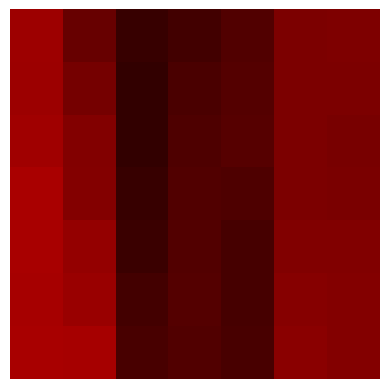

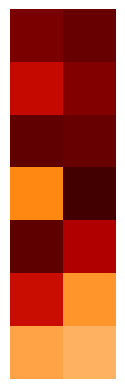

In [16]:
log_p_val = np.log10(p_val)
heatmap(log_p_val, [[7,7],[7,7],[7,2],[7,7],[7,7],[7,2],[7,7],[7,2],[7,7],[7,2]], 
        cmap='gist_heat_r', min=np.min(log_p_val), max=np.max(log_p_val), flip=True, axes=False, colorbar=False)

In [210]:
from sklearn.inspection import permutation_importance

In [190]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


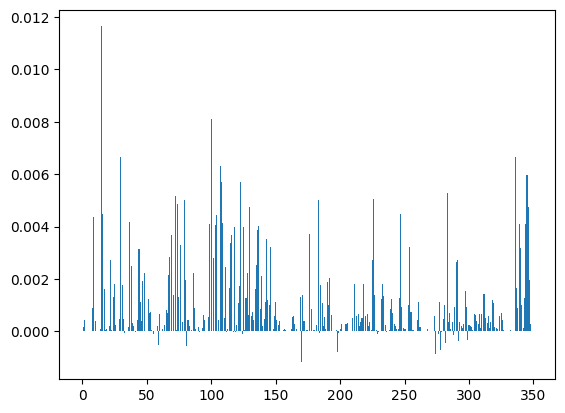

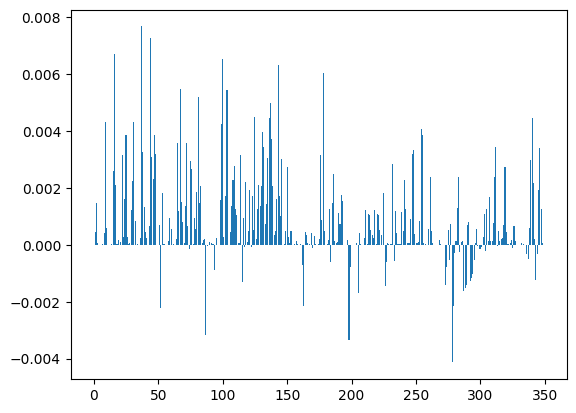

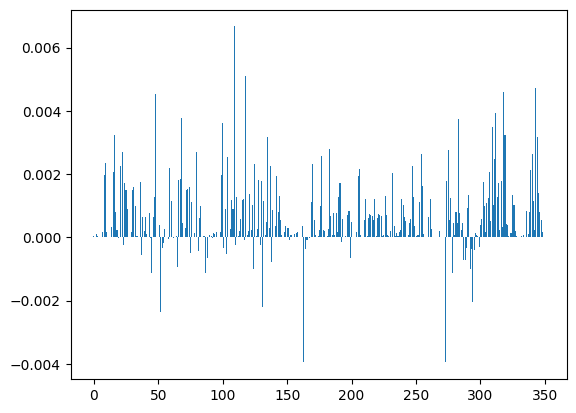

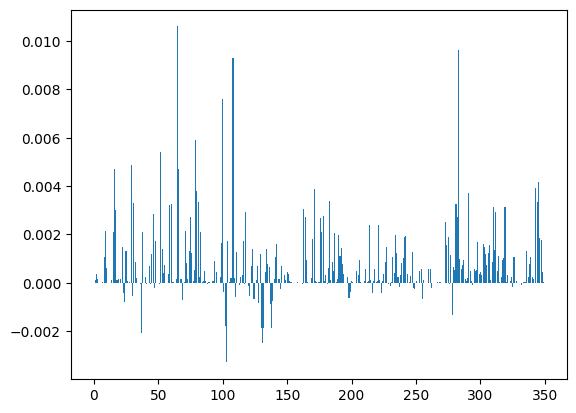

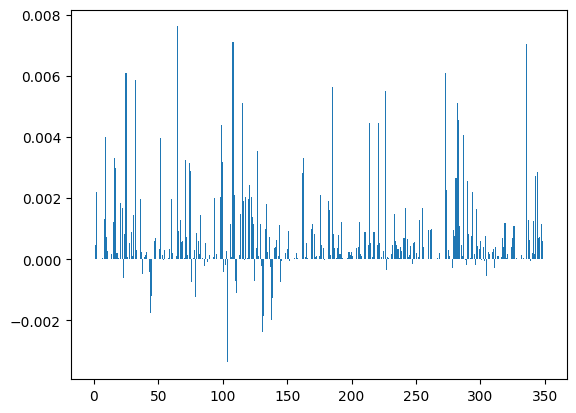

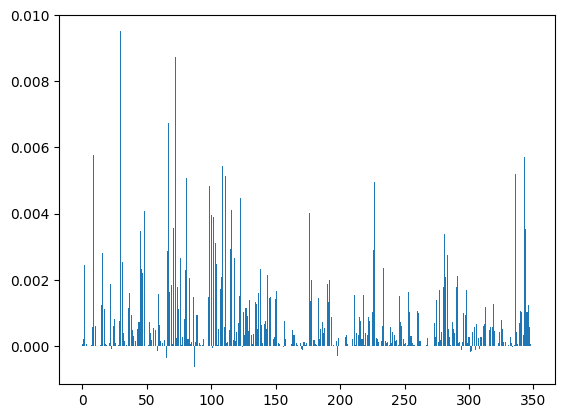

[SVR(), SVR(), SVR(), SVR(), SVR(), SVR()]

In [191]:
importance_test(positive, negative, 6, True)

In [208]:
temp = pd.DataFrame()
for i in range(3):
    temp = pd.concat([temp, pd.DataFrame({'feature ' + str(i):np.random.normal(size=100)})], axis=1)
temp = pd.concat([temp, pd.DataFrame({'Result':temp.iloc[:,0]+temp.iloc[:,1]})], axis=1)
temp

,feature 0,feature 1,feature 2,Result
0,-0.253457,-1.492040,0.341156,-1.745497
1,0.410585,-0.272827,1.140392,0.137758
2,0.063949,1.602706,-1.097609,1.666656
3,-0.558808,-0.281031,0.331232,-0.839839
4,-0.663128,-0.217049,-1.179798,-0.880176
...,...,...,...,...
95,-1.190280,-1.059807,1.454894,-2.250087
96,1.093280,0.679879,0.229951,1.773160
97,-1.564917,1.808614,0.163575,0.243697
98,-0.612358,1.585699,0.920257,0.973341


In [218]:
model.predict([[1,1,0], [0,1,0], [0,1,0], [0,1,0], [0,1,0], [0,1,0], [0,1,0], [0,1,0]])

C:\Users\justi\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


array([1.98797641, 1.08053054, 1.08053054, 1.08053054, 1.08053054,
       1.08053054, 1.08053054, 1.08053054])

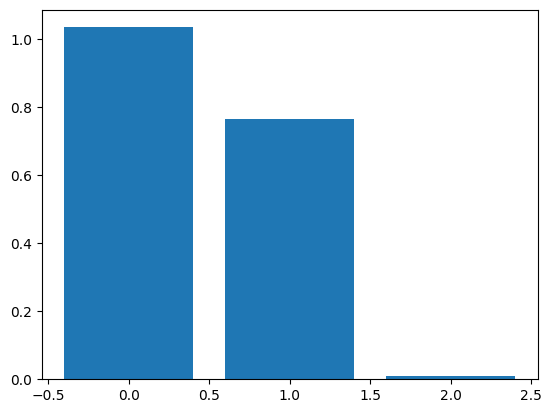

In [211]:
X = temp.drop(['Result'], axis=1)
y = temp['Result']

model = SVR().fit(X, y)
results = permutation_importance(model, X, y, n_repeats=20)
# get importance
importance = results.importances_mean
# plot feature importance
plt.bar([x for x in range(len(importance))], importance)
plt.show()